In [1]:
import os
import math
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from utils import Extractor
from circle_fit import taubinSVD
from paddleocr import PaddleOCR

In [2]:
ppocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/27 14:48:20] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

In [3]:
extractor = Extractor()
extractor.load_model()

# GG Nest Audio

In [7]:
path = "hailu"
ims = os.listdir(path)
imgs = [i for i in ims if ".jpg" in i]
img_path = os.path.join(path,random.choice(imgs))
print("img_path: ",img_path)

img_path:  hailu/D9A0B22D-8F1E-4B22-AE30-31185B62A0CC_1_201_a copy.jpg


img shape: (2268, 4032, 3)
mask shape: (3104, 4192)


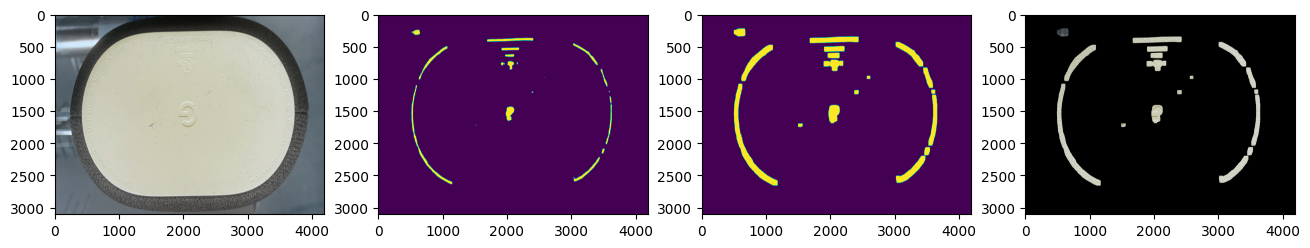

In [8]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img = cv2.imread(img_path)
img = cv2.rotate(img,cv2.ROTATE_180)

mask = extractor.get_mask(img)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))

# and mask
res = cv2.bitwise_and(img_resize,img_resize,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img_resize)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

(673, 273)
(1101, 489)
(1175, 2595)
(1562, 1698)
(2432, 359)
(2433, 1181)
(2613, 960)


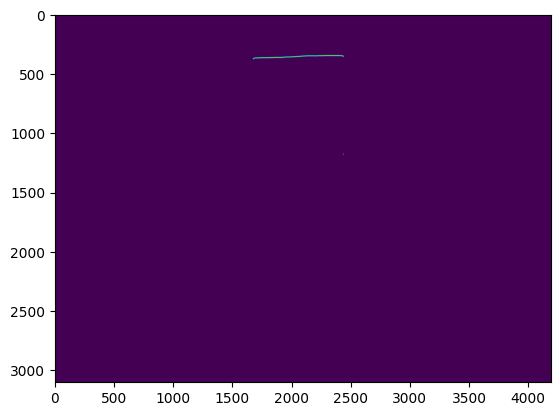

In [9]:
w,h = dilate.shape

v_lines = []
c = []
for i in range(w):
    v_line = dilate[:,i:i+1]
    pos = cv2.findNonZero(v_line) #x,y
    if pos is not None:
        c.append((i,pos[0][0][-1]))
    v_lines.append(v_line)
    
blank = np.zeros_like(dilate)

C= []
c_sub = []
p0 = c[0]
DMAX = 80
for i in range(len(c)):
    p = c[i]
    c_sub.append(p)
    d = cv2.norm(np.array(p),np.array(p0))
    if d > DMAX:
        C.append(c_sub)
        c_sub = []
        print(p0)
    p0 = p
    
C.append(c_sub) # the final c_sub is your circle

L = [len(i) for i in C]
c_sub = C[np.argmax(L)]

blank = np.zeros_like(dilate)
for p in c_sub:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

# GG Home Mini

In [4]:
def extract(img):

    img = cv2.rotate(img,cv2.ROTATE_180)
    
    k = 45
    kernel = np.ones((k,k),np.uint8)

    mask = extractor.get_mask(img)
    dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)

    img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))
    
    w,h = dilate.shape

    v_lines = []
    c = []
    for i in range(w):
        v_line = dilate[:,i:i+1]
        pos = cv2.findNonZero(v_line) #x,y
        if pos is not None:
            c.append((i,pos[0][0][-1]))
        v_lines.append(v_line)

    C= []
    c_sub = []
    p0 = c[0]
    DMAX = 80
    for i in range(len(c)):
        p = c[i]
        c_sub.append(p)
        d = cv2.norm(np.array(p),np.array(p0))
        if d > DMAX:
            C.append(c_sub)
            c_sub = []
            #print(p0)
        p0 = p

    C.append(c_sub) # the final c_sub is your circle

    L = [len(i) for i in C]
    c_sub = C[np.argmax(L)]
    
    xc, yc, r, sigma = taubinSVD(c_sub)
    r = int(r) +100
    d = r*2
    cp = (int(xc),int(yc))
    warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
    
    straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
    im = np.hstack([straightened,straightened])
    im = im[:,2500:8000]
    cv2.imwrite('debug.jpg',im)
    im = im + 0.2 * im
    res = ppocr.ocr(im,det=True,rec=True,cls=False)
    
    return res

In [5]:
def infer(res):
    model = 'n/a'
    serial = 'n/a'
    for r in res[0]:
        t=r[1][0].lower()
        # infer model
        count = t.count('h2c')
        if count >= 1:
            model = 'H2C'
        # infer serial 14 digit
        if len(t)>=14:
            for i in range(len(t)):
                s = t[i:i+14]
                if all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]])\
                and serial =='n/a':
                    serial = s
    return model,serial

# survey

- ok: 1,3,6,7,10,11,12,13,14,15,16,18
- mistake: 2,4,5,8,9
- dismiss: 17
- fail:

edit light condition

In [6]:
file = 'obj2/img2.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model,model.upper()=="H2C"," Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:43:26] ppocr DEBUG: dt_boxes num : 7, elapse : 0.25546693801879883
[2023/01/27 07:43:26] ppocr DEBUG: rec_res num  : 7, elapse : 0.2921292781829834
[[[[[36.0, 70.0], [1216.0, 95.0], [1213.0, 232.0], [33.0, 206.0]], ('MadeinThailand 05041HFAP6VYBO', 0.8211672306060791)], [[[4462.0, 120.0], [5480.0, 87.0], [5484.0, 229.0], [4466.0, 262.0]], ('Modelt H2C GocgleFCCID.A', 0.826526939868927)], [[[2486.0, 1278.0], [2641.0, 1278.0], [2641.0, 1384.0], [2486.0, 1384.0]], ('Sn', 0.595569908618927)]]] 


Img:  obj2/img2.jpg  Model:  H2C True  Serial( 14 ): 05041HFAP6VYBO True


# orignal

In [7]:
file = 'obj2/img17.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:43:42] ppocr DEBUG: dt_boxes num : 1, elapse : 0.1557912826538086
[2023/01/27 07:43:42] ppocr DEBUG: rec_res num  : 1, elapse : 0.15566468238830566
[[[[[1054.0, 199.0], [5145.0, 205.0], [5145.0, 342.0], [1054.0, 336.0]], ('Modelt H2CGocgle FCCID:A4R-H2CIC:10395A-H2C CANICES-3(B)/NMB-3(B)Made in Thaiand 0504HFAP6VYBO', 0.8948997259140015)]]] 


Img:  obj2/img17.jpg  Model:  H2C True  Serial( 13 ): 0504HFAP6VYBO False


# cut

In [8]:
file = 'obj2/aug1.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:43:54] ppocr DEBUG: dt_boxes num : 1, elapse : 0.14600443840026855
[2023/01/27 07:43:54] ppocr DEBUG: rec_res num  : 1, elapse : 0.041342735290527344
[[[[[719.0, 158.0], [2029.0, 189.0], [2025.0, 366.0], [715.0, 335.0]], ('ModetH2CGOgleFCCDA4R-H20', 0.8599870204925537)]]] 


Img:  obj2/aug1.jpg  Model:  H2C True  Serial( 2 ): 20 False


# rotated

In [9]:
file = 'obj2/aug2.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:44:04] ppocr DEBUG: dt_boxes num : 0, elapse : 0.14900660514831543
[2023/01/27 07:44:04] ppocr DEBUG: rec_res num  : 0, elapse : 7.152557373046875e-07
[[]] 


Img:  obj2/aug2.jpg  Model:  N/A False  Serial( 3 ): N/A False


# vertical skew

In [10]:
file = 'obj2/aug3.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:44:10] ppocr DEBUG: dt_boxes num : 0, elapse : 0.1708528995513916
[2023/01/27 07:44:10] ppocr DEBUG: rec_res num  : 0, elapse : 7.152557373046875e-07
[[]] 


Img:  obj2/aug3.jpg  Model:  N/A False  Serial( 3 ): N/A False


# horizontal skew

In [11]:
file = 'obj2/aug4.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:44:19] ppocr DEBUG: dt_boxes num : 0, elapse : 0.14347338676452637
[2023/01/27 07:44:19] ppocr DEBUG: rec_res num  : 0, elapse : 7.152557373046875e-07
[[]] 


Img:  obj2/aug4.jpg  Model:  N/A False  Serial( 3 ): N/A False


# low brightness

In [12]:
file = 'obj2/aug5.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:44:28] ppocr DEBUG: dt_boxes num : 1, elapse : 0.14986038208007812
[2023/01/27 07:44:28] ppocr DEBUG: rec_res num  : 1, elapse : 0.15598273277282715
[[[[[1054.0, 199.0], [5145.0, 205.0], [5145.0, 342.0], [1054.0, 336.0]], ('Modet H2CGoogle FCCID:A4R-H2CIC:10395A-H2C CANICES-3(B)/NMB-3(B)Made in Thaiand 05041HFAP6VYBO', 0.8980642557144165)]]] 


Img:  obj2/aug5.jpg  Model:  H2C True  Serial( 14 ): 05041HFAP6VYBO True


# noise

In [13]:
file = 'obj2/aug7.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/27 07:44:37] ppocr DEBUG: dt_boxes num : 0, elapse : 0.1475658416748047
[2023/01/27 07:44:37] ppocr DEBUG: rec_res num  : 0, elapse : 7.152557373046875e-07
[[]] 


Img:  obj2/aug7.jpg  Model:  N/A False  Serial( 3 ): N/A False


# step by step

img shape: (3684, 4912, 3)
mask shape: (3104, 4192)


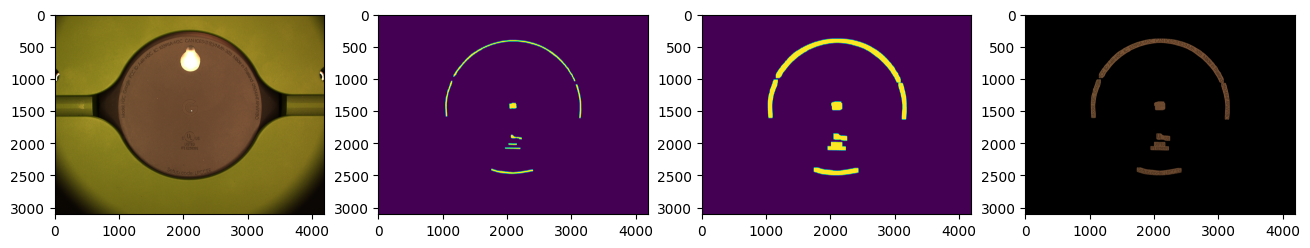

In [14]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img = cv2.imread('obj2/img16.jpg')
img = cv2.rotate(img,cv2.ROTATE_180)

mask = extractor.get_mask(img)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))

# and mask
res = cv2.bitwise_and(img_resize,img_resize,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img_resize)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

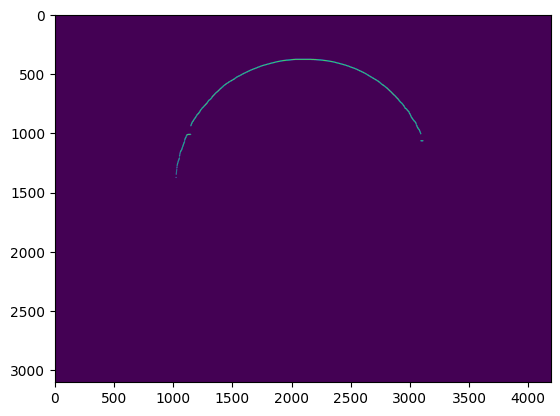

In [15]:
w,h = dilate.shape

v_lines = []
c = []
for i in range(w):
    v_line = dilate[:,i:i+1]
    pos = cv2.findNonZero(v_line) #x,y
    if pos is not None:
        c.append((i,pos[0][0][-1]))
    v_lines.append(v_line)
    
blank = np.zeros_like(dilate)

C= []
c_sub = []
p0 = c[0]
DMAX = 80
for i in range(len(c)):
    p = c[i]
    c_sub.append(p)
    d = cv2.norm(np.array(p),np.array(p0))
    if d > DMAX:
        C.append(c_sub)
        c_sub = []
        print(p0)
    p0 = p
    
C.append(c_sub) # the final c_sub is your circle

L = [len(i) for i in C]
c_sub = C[np.argmax(L)]

blank = np.zeros_like(dilate)
for p in c_sub:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

xc=2101, yc=1460, r=1134, sigma=4.328501652022898


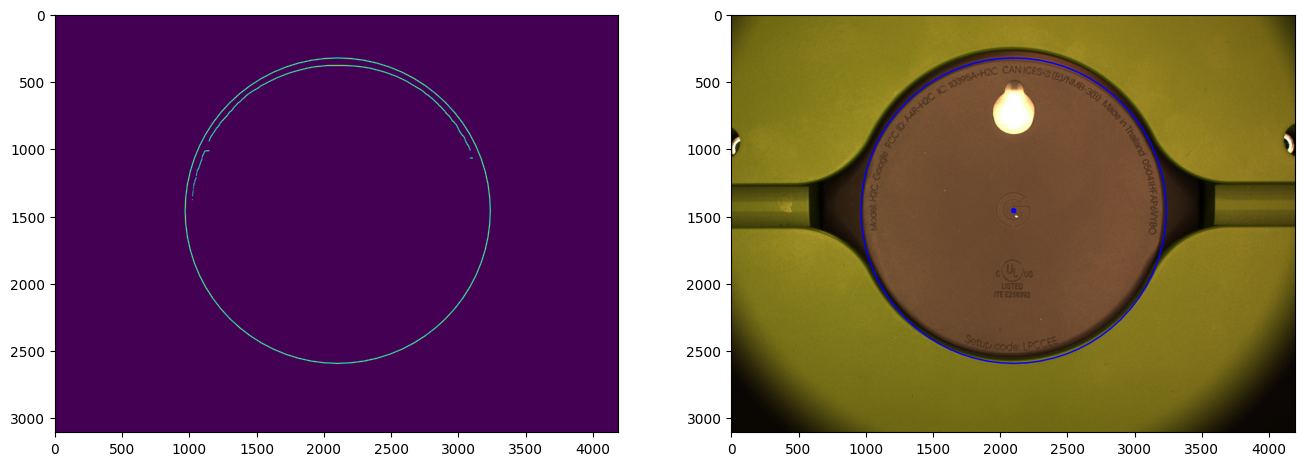

In [16]:
xc, yc, r, sigma = taubinSVD(c_sub)
r = int(r) +50
d = r*2
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

cv2.circle(blank,(int(xc),int(yc)),int(r),(255),6)
cv2.circle(img_resize,(int(xc),int(yc)),20,(0,0,255),-1)
cv2.circle(img_resize,(int(xc),int(yc)),r,(0,0,255),10)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,10))
axes[0].imshow(blank)
axes[1].imshow(img_resize)

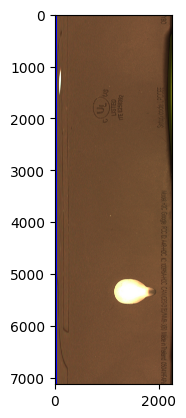

In [17]:
cp = (int(xc),int(yc))
warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
plt.imshow(warped)

[2023/01/27 07:45:04] ppocr DEBUG: dt_boxes num : 1, elapse : 0.14011836051940918
[2023/01/27 07:45:04] ppocr DEBUG: rec_res num  : 1, elapse : 0.14850425720214844
[[[[[894.0, 94.0], [4818.0, 106.0], [4818.0, 242.0], [894.0, 230.0]], ('ModetH2C GocgleFCCID:A4R-H2C IC:10395A-H2CCANICES-3(B)/NMB-3(B)Madein Thaiand05041HFAP6VYBO', 0.9124192595481873)]]] 



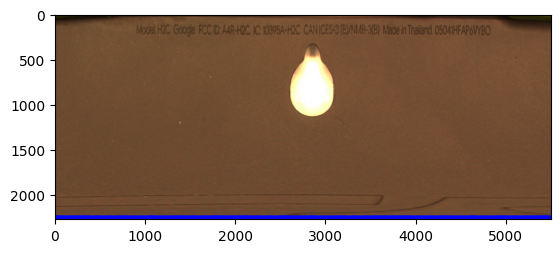

In [18]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
im = np.hstack([straightened,straightened])
im = im[:,2500:8000]
#cv2.imwrite('straight.jpg',im)
res1 = ppocr.ocr(im,det=True,rec=True,cls=False)
print(res1,"\n")
plt.imshow(im)

In [19]:
serial = 'n/a'

res = extract(img)
print(res)

for r in res[0]:

    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                serial = s
                
print("Model: ",model,"Serial: ",serial.upper())

[2023/01/27 07:45:08] ppocr DEBUG: dt_boxes num : 6, elapse : 0.14571046829223633
[2023/01/27 07:45:08] ppocr DEBUG: rec_res num  : 6, elapse : 0.2841155529022217
[[[[[37.0, 46.0], [1227.0, 78.0], [1224.0, 213.0], [33.0, 182.0]], ('Made in Thailand 05041HFAP6VYBO', 0.9252237677574158)], [[[4461.0, 126.0], [5473.0, 87.0], [5479.0, 234.0], [4467.0, 273.0]], ('Modet H2C Gocgle FCC ID:A', 0.8731806874275208)], [[[2469.0, 1269.0], [2590.0, 1269.0], [2590.0, 1363.0], [2469.0, 1363.0]], ('Sn', 0.7235701084136963)]]]
Model:  n/a Serial:  05041HFAP6VYBO


In [20]:
def extract(img):
    
    # 7,10,11,13 (None)
    # 2,6,8,9,15 (1=i)
    # 1,3,4,5,12,14
    img = cv2.rotate(img,cv2.ROTATE_180)
    
    k = 45
    kernel = np.ones((k,k),np.uint8)

    mask = extractor.get_mask(img)
    dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)

    img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))
    
    w,h = dilate.shape

    v_lines = []
    c = []
    for i in range(w):
        v_line = dilate[:,i:i+1]
        pos = cv2.findNonZero(v_line) #x,y
        if pos is not None:
            c.append((i,pos[0][0][-1]))
        v_lines.append(v_line)

    C= []
    c_sub = []
    p0 = c[0]
    DMAX = 80
    for i in range(len(c)):
        p = c[i]
        c_sub.append(p)
        d = cv2.norm(np.array(p),np.array(p0))
        if d > DMAX:
            C.append(c_sub)
            c_sub = []
            print(p0)
        p0 = p

    C.append(c_sub) # the final c_sub is your circle

    L = [len(i) for i in C]
    c_sub = C[np.argmax(L)]
    
    xc, yc, r, sigma = taubinSVD(c_sub)
    r = int(r) +50
    d = r*2
    cp = (int(xc),int(yc))
    warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
    
    straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
    im = np.hstack([straightened,straightened])
    im = im[:,2500:8000]
    
    res = ppocr.ocr(im,det=True,rec=True,cls=False)
    
    return res

(1051, 1378)
(1708, 2471)
(2410, 541)
(2992, 1975)
(3060, 1610)
[2023/01/27 07:46:17] ppocr DEBUG: dt_boxes num : 5, elapse : 0.1559154987335205
[2023/01/27 07:46:17] ppocr DEBUG: rec_res num  : 5, elapse : 0.27329444885253906
[[[[[40.0, 17.0], [1060.0, 17.0], [1060.0, 136.0], [40.0, 136.0]], ('Jein Jhaland0504HFAP6VYBO', 0.7933740019798279)], [[[4153.0, 29.0], [5452.0, 0.0], [5455.0, 135.0], [4156.0, 165.0]], ('Model H2C Gocgle FCCID:A4R-H2CIC', 0.8796936273574829)]]]
Model:  H2C Serial:  None
Model:  H2C Serial:  None


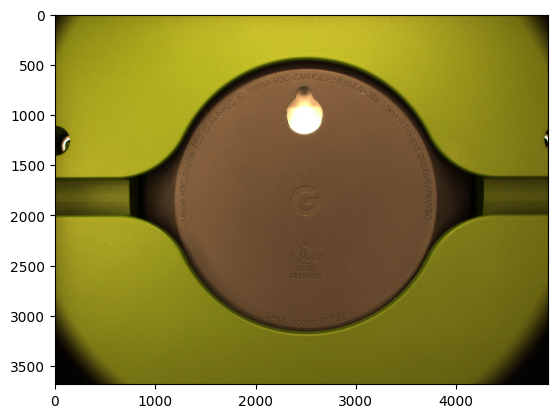

In [25]:
##### model = None
serial = None

# 7,10,11,13 (None)
# 2,6,8,9,15 (1=i)
# 1,3,4,5,12,14

img = cv2.imread('obj2/img2.jpg')

plt.imshow(img)
res = extract(img)

print(res)

for r in res[0]:

    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                serial = s
                
    print("Model: ",model,"Serial: ",serial)

# ring to rectangle

Text(0.5, 1.0, '(588, 588, 3)')

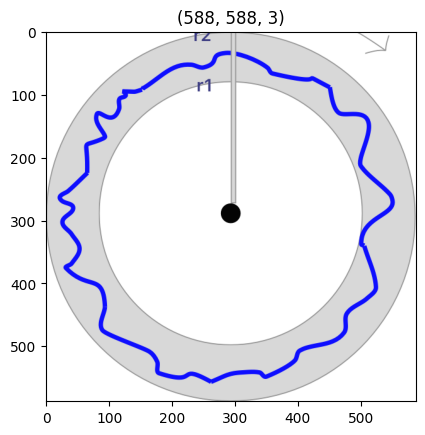

In [26]:
ring = cv2.imread('snippets/ring.png')
plt.imshow(ring)
plt.title(ring.shape)

In [27]:
factor = 0.7
size = ring.shape[0]
outer_radius = size // 2
inner_radius = int(factor*outer_radius)
print(f'outer_radius: {outer_radius}')
print(f'inner_radius: {inner_radius}')

outer_radius: 294
inner_radius: 205


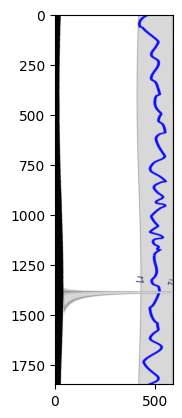

In [28]:
# Unwarp ring
cp = (outer_radius,outer_radius)
warped = cv2.warpPolar(ring, (size, int(size * math.pi)),cp, outer_radius, 0)
plt.imshow(warped)

Text(0.5, 1.0, '(588, 1847, 3)')

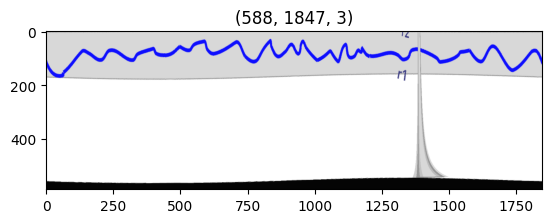

In [29]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(straightened)
plt.title(straightened.shape)

True

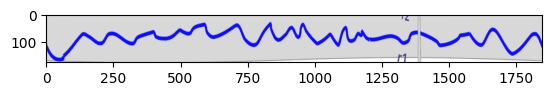

In [30]:
# Crop to ring only
cropped = straightened[: int(straightened.shape[0] * (1 - factor)), :]
plt.imshow(cropped)
cv2.imwrite("straight.png", cropped)

# references

[使用 OpenVINO™ 实现 Paddle的PGNet 推理程序
](https://aistudio.baidu.com/aistudio/projectdetail/5208774?channelType=0&channel=0)

[使用 OpenVINO™ 实现 Paddle的PGNet 推理程序](https://blog.csdn.net/m0_63642362/article/details/128389867)

[Algorithm Overview](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/algorithm_overview_en.md)

[SVTR](https://viblo.asia/p/svtr-net-loi-giai-hoan-hao-cho-bai-toan-ocr-924lJg3a5PM)

[OCR Model List（V3, updated on 2022.4.28）](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/models_list_en.md)

[PP-OCR Model Zoo](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/models_en.md#pp-ocr-model)

[Python Inference for PP-OCR Model Zoo](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/inference_ppocr_en.md)

[PaddleOCR Model Inference Parameter Explanation](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/inference_args_en.md)

[Inference Based on Python Prediction Engine](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/inference_en.md)

[Fine-tune](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/finetune_en.md)

[Benchmark](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/benchmark_en.md)

[ring-to-a-rectangle](https://stackoverflow.com/questions/71416458/how-to-map-points-from-a-surface-of-2d-ring-to-a-rectangle)

[using-dilation-in-only-one-direction](https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction)

[straightening-contoured-rectangles](https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python)

[How to convert curves in images to lines in Python?](https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python)

[paddleocr](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/paddleocr.py)

[Robust Scene Text Recognition with Automatic Rectification](https://arxiv.org/pdf/1603.03915.pdf)

[Spatial Transformer Networks](https://arxiv.org/pdf/1506.02025.pdf)